<div align="center">
  <span style="font-size:50px; color:maroon;"><b>
      Datos Geofísica
  </b>
  </span>
</div>

In [4]:
import pandas as pd

# Leer el archivo original
df = pd.read_csv('DataICNCorr26.txt', delimiter='\t')

# Convertir la columna 'Fecha_Hora' a tipo datetime
df['Fecha_Hora'] = pd.to_datetime(df['Fecha_Hora'], format='%Y-%m-%d %H:%M:%S')

# Asignar la zona horaria de CDMX
df['Fecha_Hora_CDMX'] = df['Fecha_Hora'].dt.tz_localize('America/Mexico_City')

# Convertir a UTC
df['Fecha_Hora_UTC'] = df['Fecha_Hora_CDMX'].dt.tz_convert('UTC')

# Formatear la columna de UTC en el formato deseado
df['Fecha_Hora_UTC'] = df['Fecha_Hora_UTC'].dt.strftime('%Y-%m-%d %H:%M:%S')

# Eliminar columnas intermedias si no son necesarias
df = df[['Fecha_Hora_UTC', 'Data', 'Presion(mbar)', 'Temperatura(C)', 'ICN_corr']]

# Guardar el archivo resultante
df.to_csv('DataICNCorr_utc26.txt', sep='\t', index=False)

# Imprimir el DataFrame para verificar
#print(df)

In [28]:
import pandas as pd

# Cargar el archivo de texto
archivo_entrada = "NeutronData26.txt"
df = pd.read_csv(archivo_entrada, delimiter='\t')

# Combinar las columnas 'Date' y 'Time' en una nueva columna 'Fecha_Hora_LT'
df['Fecha_Hora'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])

# Eliminar las columnas 'Date' y 'Time'
df = df.drop(['Date', 'Time'], axis=1)

# Reorganizar las columnas para que 'Fecha_Hora_LT' sea la primera
df = df[['Fecha_Hora'] + [col for col in df.columns if col != 'Fecha_Hora']]

columnas_a_guardar = ['Fecha_Hora', 'NeutronData']

df[columnas_a_guardar].to_csv('dataORC_utc26.txt', sep='\t', index=False)

# Mostrar el DataFrame resultante
print(df[columnas_a_guardar])

              Fecha_Hora  NeutronData
0    2026-01-01 00:00:00     757924.0
1    2026-01-01 01:00:00     753716.0
2    2026-01-01 02:00:00     755552.0
3    2026-01-01 03:00:00     755029.0
4    2026-01-01 04:00:00     756800.0
...                  ...          ...
1305 2026-02-24 12:00:00     757350.0
1306 2026-02-24 13:00:00     756056.0
1307 2026-02-24 14:00:00     756981.0
1308 2026-02-24 15:00:00     760188.0
1309 2026-02-24 16:00:00     757603.0

[1310 rows x 2 columns]


<div align="center">
  <span style="font-size:50px; color:maroon;"><b>
      Comparativa con los datos del ICN corregidos
  </b>
  </span>
</div>

In [3]:
import pandas as pd


#ARCHIVOS TXT POR LEER
data1 = pd.read_csv("DataICNCorr_utc26.txt", delimiter='\t')
data2 = pd.read_csv("dataORC_utc26.txt", delimiter='\t')
#data3 = pd.read_csv("dataORC_unc_utc.txt", delimiter='\t')
#data4 = pd.read_csv("dataORC_LT.txt", delimiter='\t')

# Seleccionar las columnas a combinar
Date = data1['Fecha_Hora_UTC']
Data = data1['Data']
DataCorr = data1['ICN_corr']
Pressure = data1['Presion(mbar)']
Temperatura = data1['Temperatura(C)']
cData = data2['NeutronData']
#uData = data3['NeutronData_unc']
#Pressure = data3['Pressure(mb)']


# Crear un nuevo DataFrame con las columnas combinadas
data_combinada = pd.concat([Date, Data, DataCorr, Pressure, Temperatura, cData], axis=1)

# Guardar el nuevo archivo combinado
data_combinada.to_csv("dataTotalUTC26.txt", sep='\t', index=False)

#print('Se creó el archivo', data_combinada)

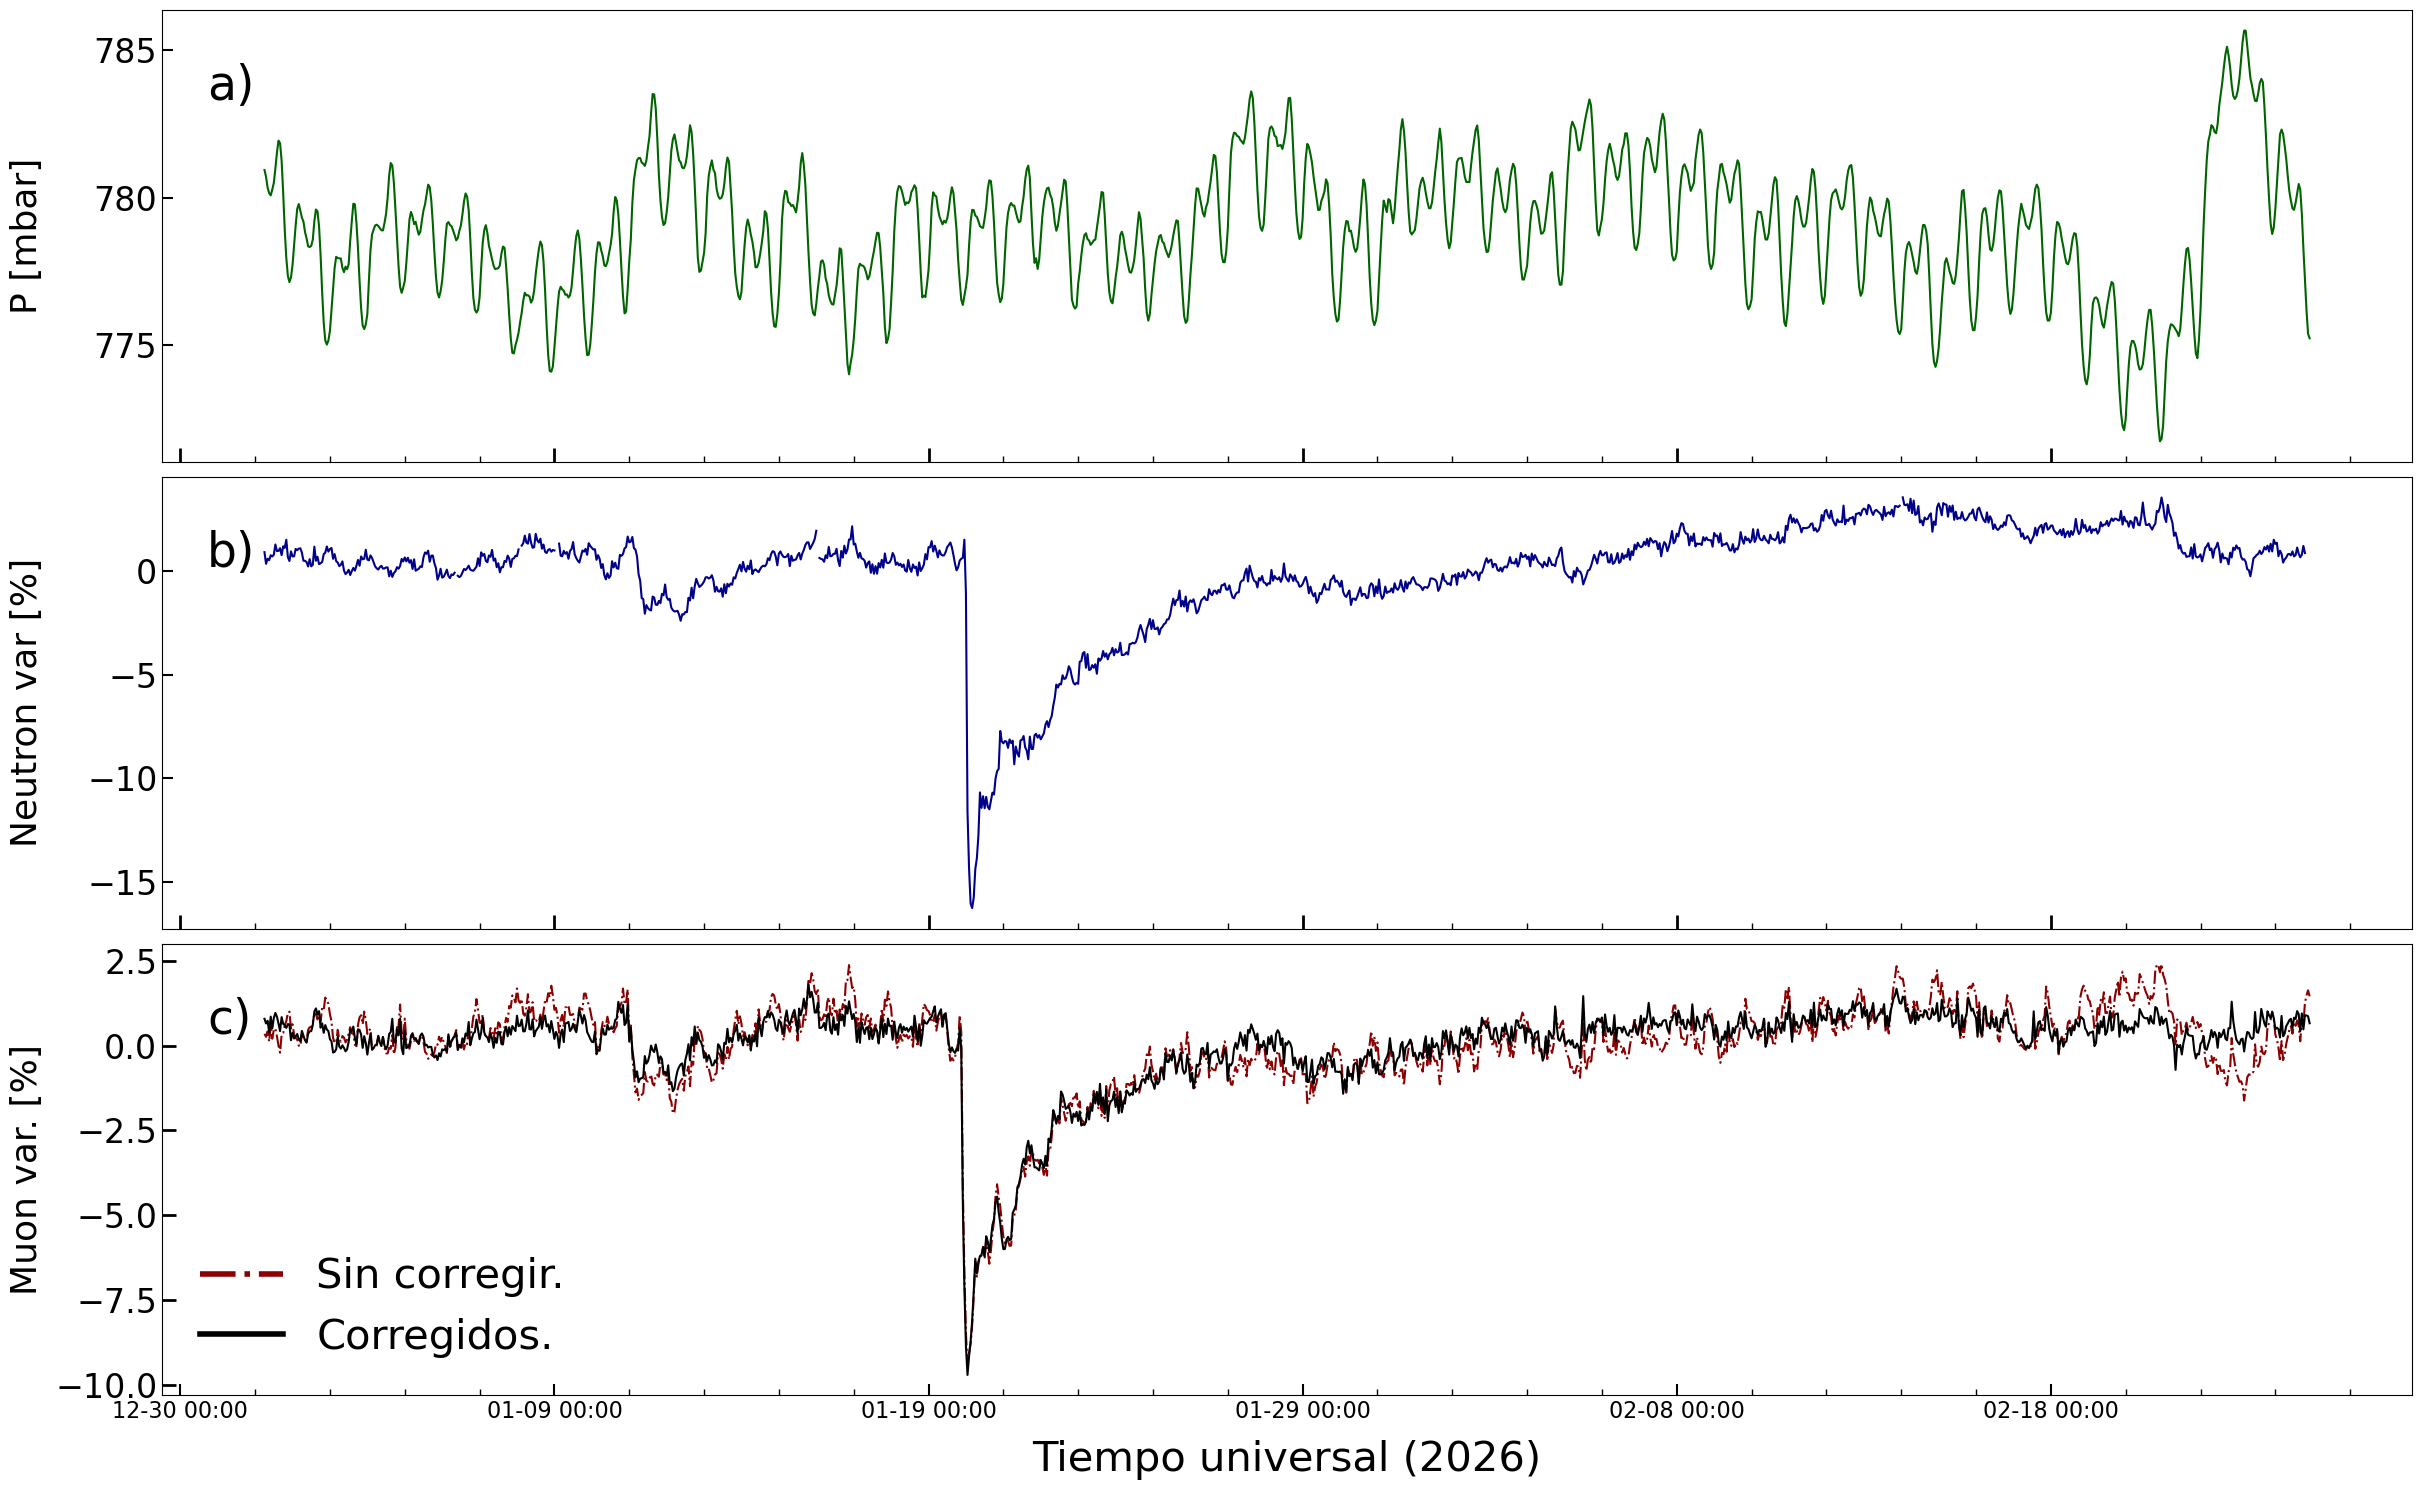

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter, HourLocator, DayLocator, MonthLocator
from matplotlib.lines import Line2D

# Leer el archivo de texto
data = pd.read_csv("dataTotalUTC26.txt", delimiter='\t')

# Convertir la columna de fechas a formato datetime
data['Fecha_Hora'] = pd.to_datetime(data['Fecha_Hora_UTC'], format='%Y-%m-%d %H:%M:%S')

# Crear tres subplots compartiendo el eje x
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(24, 15), sharex=True)

# Subplot 1: Pressure (Presión)
ax1.plot(data['Fecha_Hora'], data['Presion(mbar)'], label='Pressure', color='darkgreen')
ax1.set_ylabel('P [mbar]', fontsize=26, labelpad=8)
ax1.text(0.02, 0.8, 'a)', transform=ax1.transAxes, fontsize=34, color='black')  # Cambiado a ax1
ax1.tick_params(axis='x', which='both', direction='in', length=10, width=2, top=False, bottom=True, labelsize=24)
ax1.tick_params(axis='y', which='both', length=8, width=1.5, direction='in', top=False, bottom=True, labelsize=24)
ax1.xaxis.set_minor_locator(DayLocator(interval=2)) 
ax1.tick_params(axis='x', which='minor', direction='in', length=4, width=1, bottom=True)


# Subplot 2: Geofisica 
meangeo = data['NeutronData'].mean()
ax2.plot(data['Fecha_Hora'], 100*(data['NeutronData'] - meangeo)/meangeo, label='CRO-UNAM', color='darkblue')

#ax2.plot(data['Fecha_Hora'], data['NeutronData'], label='CRO-UNAM', color='darkblue')

ax2.set_ylabel('Neutron var [%]', fontsize=26, labelpad=8)
ax2.text(0.02, 0.8, 'b)', transform=ax2.transAxes, fontsize=34, color='black')  # Cambiado a ax2
ax2.tick_params(axis='x', which='both', direction='in', length=10, width=2, top=False, bottom=True, labelsize=24)
ax2.tick_params(axis='y', which='both', length=8, width=1.5, direction='in', top=False, bottom=True, labelsize=24)
ax2.xaxis.set_minor_locator(DayLocator(interval=2)) 
ax2.tick_params(axis='x', which='minor', direction='in', length=4, width=1, bottom=True)


# Subplot 3: MD-ICN 
CorrMean = data['ICN_corr'].mean()
UncMean = data['Data'].mean()

ax3.plot(data['Fecha_Hora'], 100*(data['Data'] - UncMean)/UncMean, label='Without corr.', color='darkred', linestyle='-.')
ax3.plot(data['Fecha_Hora'], 100*(data['ICN_corr'] - CorrMean)/CorrMean, label='With corr.', color='black')

#ax3.plot(data['Fecha_Hora'], data['Data'], label='Without corr.', color='darkred', linestyle='-.')
#ax3.plot(data['Fecha_Hora'], data['ICN_corr'] , label='With corr.', color='black')


ax3.set_ylabel('Muon var. [%]', fontsize=26, labelpad=8)
ax3.text(0.02, 0.8, 'c)', transform=ax3.transAxes, fontsize=34, color='black') 

custom_lines = [
    Line2D([0], [0], color='darkred', lw=4, linestyle='-.'),  
    Line2D([0], [0], color='black', lw=4, linestyle='-')    
]
ax3.legend(custom_lines, ['Sin corregir.', 'Corregidos.'], loc='lower left', fontsize=30, frameon=False, fancybox=False)
ax3.tick_params(axis='y', which='both', length=10, width=2, direction='in', top=False, bottom=True, labelsize=24)
ax3.tick_params(axis='x', which='both', direction='in', length=8, width=1.5, top=False, bottom=True, labelsize=24)
ax3.tick_params(axis='x', which='minor', direction='in', length=4, width=1, bottom=True)




ax3.set_xlabel('Tiempo universal (2026)', fontsize=30, labelpad=12)
ax3.xaxis.set_major_locator(DayLocator(interval=10)) 
ax3.xaxis.set_major_formatter(DateFormatter('%m-%d %H:%M'))
ax3.tick_params(axis='x', labelsize=16)

#for label in ax3.get_xticklabels():
 #   label.set_y(-0.05)

fig.align_ylabels([ax1, ax2, ax3])
plt.tight_layout()
plt.savefig('DataCombined26.png', format='png', dpi=300, bbox_inches='tight')

plt.show()

#print(CorrMean)